## 목표
- EDA 및 시각화
- 다중 분류 모델 실습 (scikit - learn)
- 분류 성능 평가 및 지표에 대한 이해

### 컬럼 설명

- gender: 학생의 성별 (M: 남성, F: 여성)
- NationaliTy: 학생의 국적
- PlaceofBirth: 학생이 태어난 국가
- StageID: 학생이 다니는 학교 (초,중,고)
- GradeID: 학생이 속한 성적 등급
- SectionID: 학생이 속한 반 이름
- Topic: 수강한 과목
- Semester: 수강한 학기 (1학기/2학기)
- Relation: 주 보호자와 학생의 관계
- raisedhands: 학생이 수업 중 손을 든 횟수
- VisITedResources: 학생이 과목 공지를 확인한 횟수
- Discussion: 학생이 토론 그룹에 참여한 횟수
- ParentAnsweringSurvey: 부모가 학교 설문에 참여했는지 여부
- ParentschoolSatisfaction: 부모가 학교에 만족했는지 여부
- StudentAbscenceDays: 학생의 결석 횟수 (7회 이상/미만)
- Class: 학생의 성적 등급 (L: 낮음, M: 보통, H: 높음)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#한글 폰트 적용
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

In [2]:
df = pd.read_csv('./xAPI-Edu-Data.csv', encoding='cp949')

In [3]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


## 피처 선택을 위한 EDA

In [4]:
#데이터 타입 및 컬럼들 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [5]:
#결측치 확인
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

### 변수 나누기

In [6]:
# 데이터 타입에 따라 컬럼 분류
categorical = df.select_dtypes(include=['object']).columns.tolist()
numeric = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


#### 범주형 변수 : gender, NationalITy, PlaceofBirth, StageID, GradeID, SectionID, Topic, Semester, Relation, ParentAnsweringSurvey, ParentschoolSatisfaction, StudentAbsenceDays, Class
#### 수치형 변수 : raisedhands, VisITedResources, AnnouncementsView, Discussion

In [7]:
def make_plots(data_frame, categorical, n_cols=3):
    # 행 수 계산
    n_rows = (len(categorical) + n_cols - 1) // n_cols
    
    # 전체 그림 크기 설정
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 5))
    
    # 축 평탄화 (1차원 배열로 변환)
    if n_rows > 1 or n_cols > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # 각 범주형 변수에 대한 그래프 그리기
    for i, column in enumerate(categorical):
        if i < len(axes):
            order = data_frame[column].value_counts().index.tolist()
            ax = sns.countplot(data=data_frame, x=column, order=order, ax=axes[i], hue=column)
            
            # 막대 위에 값 표시
            for container in ax.containers:
                ax.bar_label(container, fontsize=9)
            
            # x축 레이블 회전 (카테고리가 많을 경우)
            if len(order) > 5:
                ticks_loc = ax.get_xticks()
                ax.set_xticks(ticks_loc)
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
            ax.set_title(f'{column} 분포', fontsize=12)
            ax.set_xlabel('')  # x축 레이블 제거
    
    # 사용하지 않는 서브플롯 제거
    for i in range(len(categorical), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()


### 범주형 변수 시각화

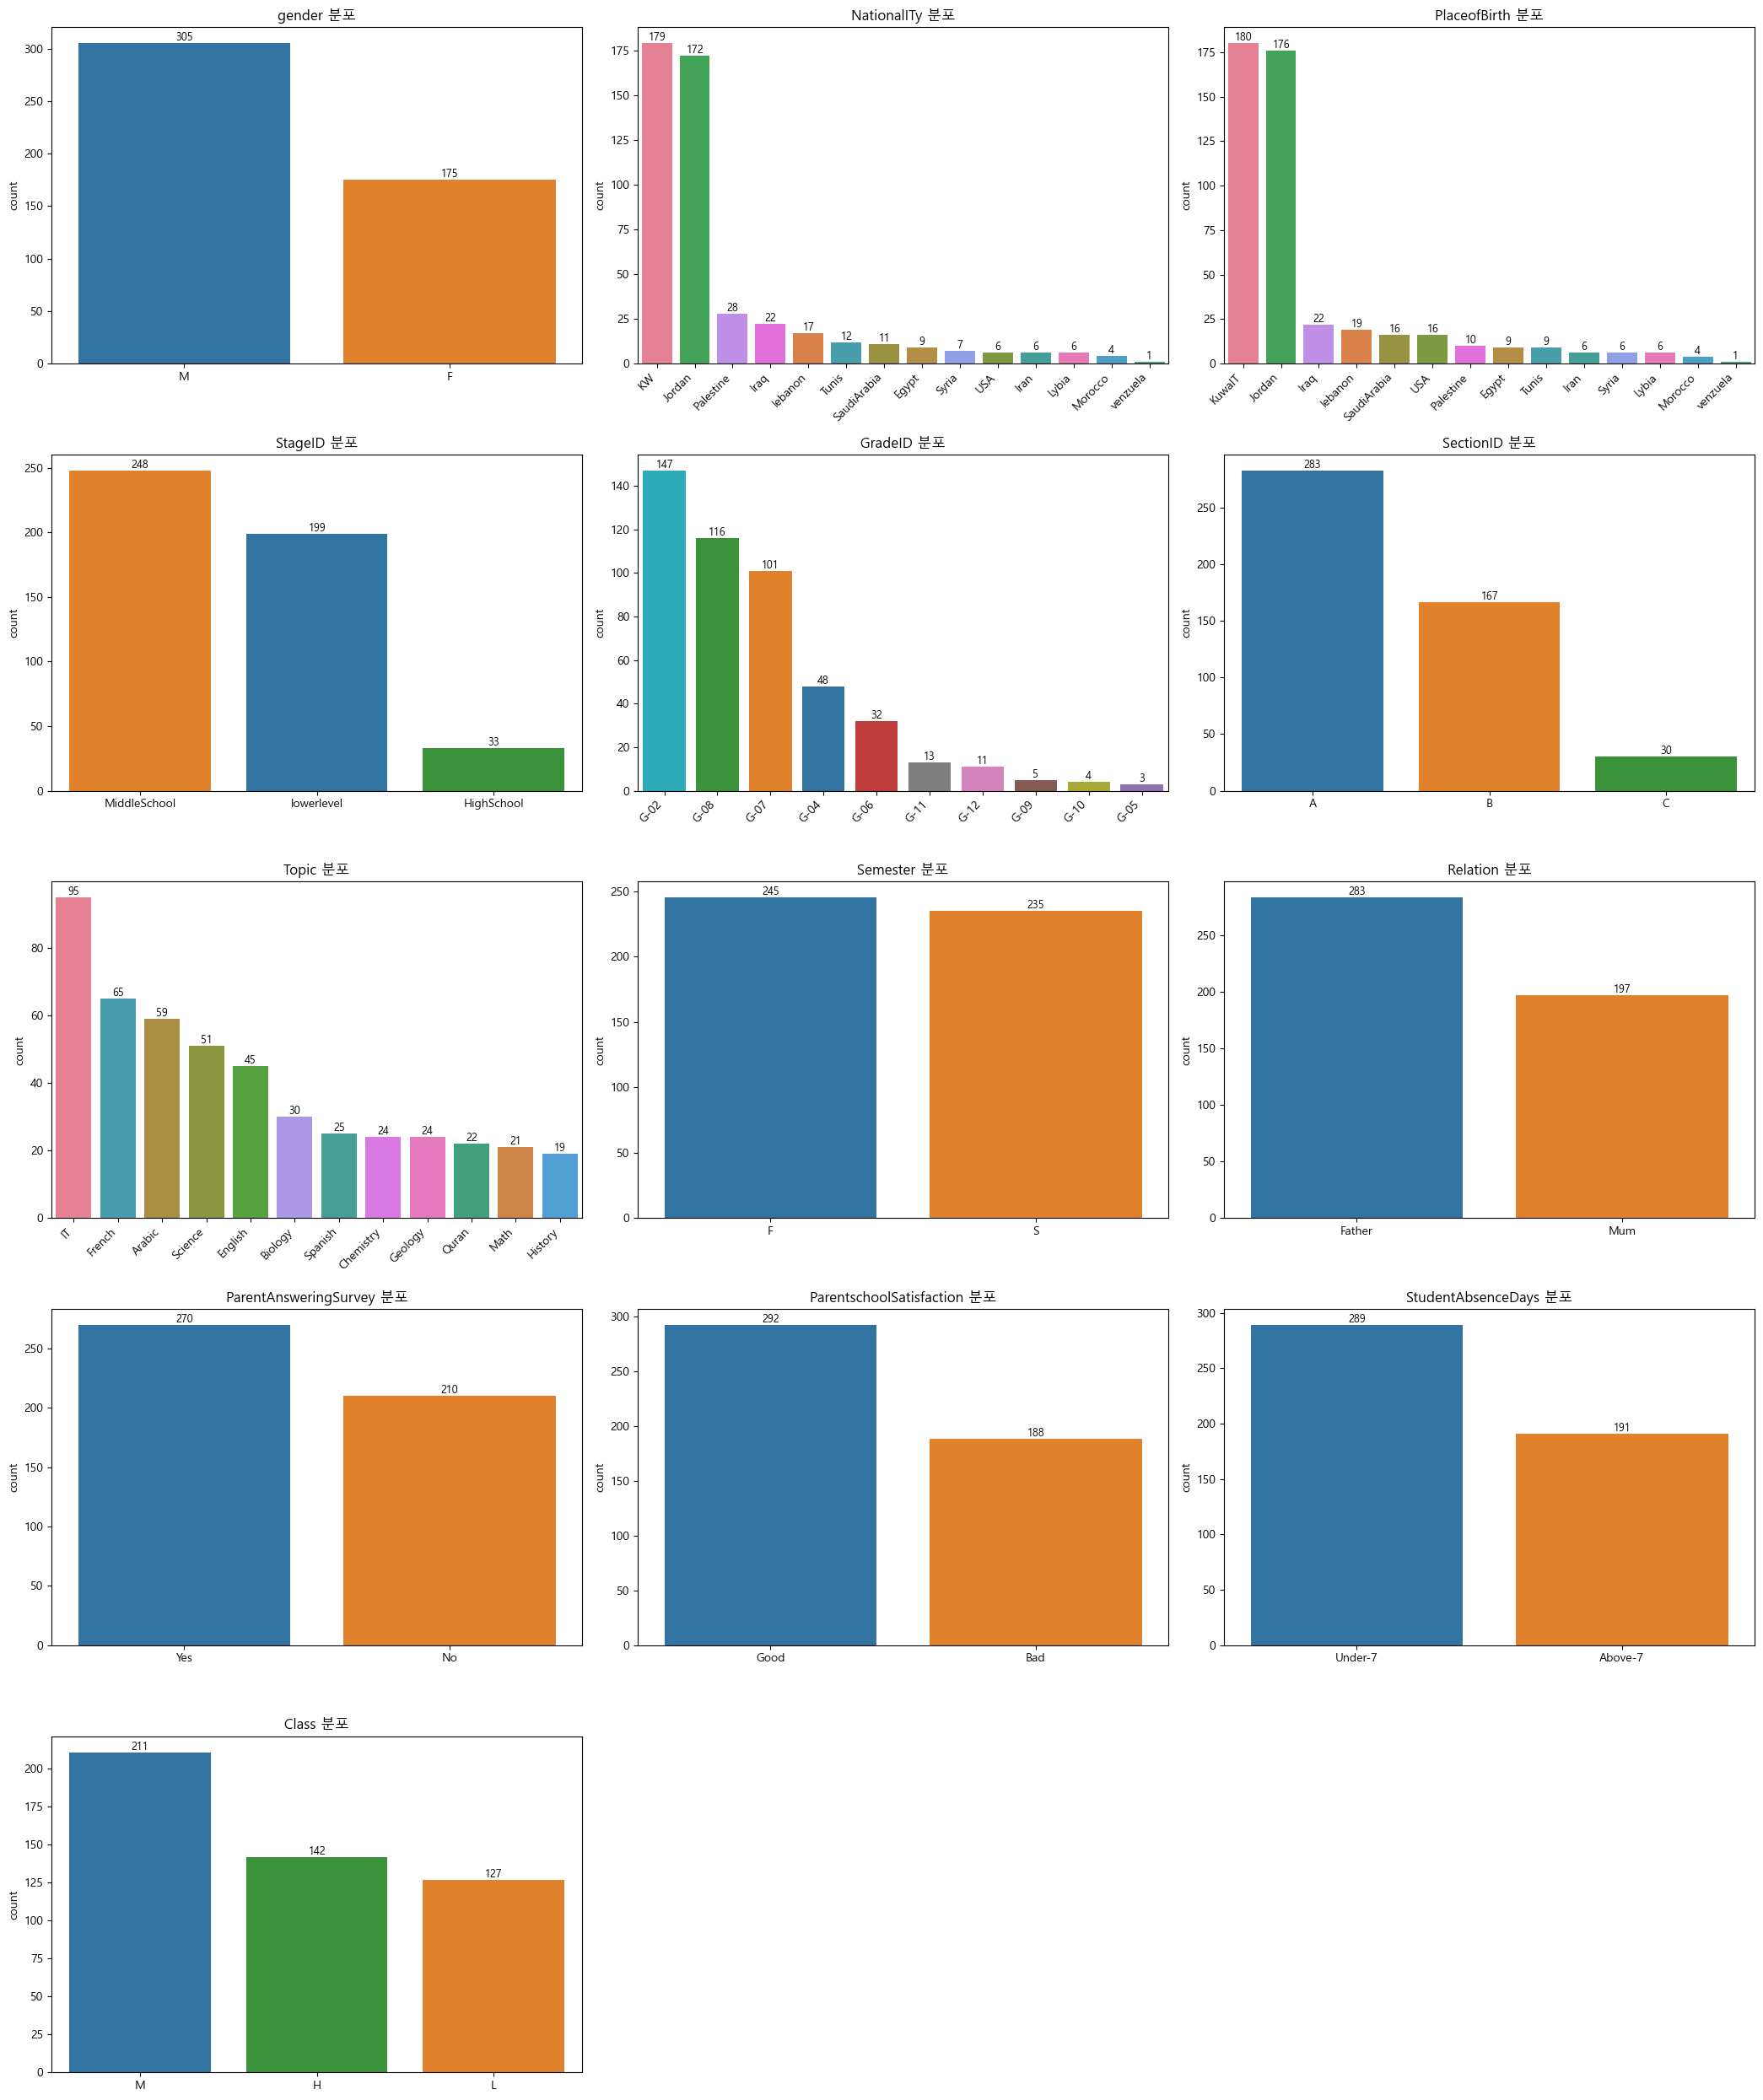

In [8]:
#범주형 변수 countplot 그리기
make_plots(df, categorical, n_cols=3)

### 수치형 변수 시각화

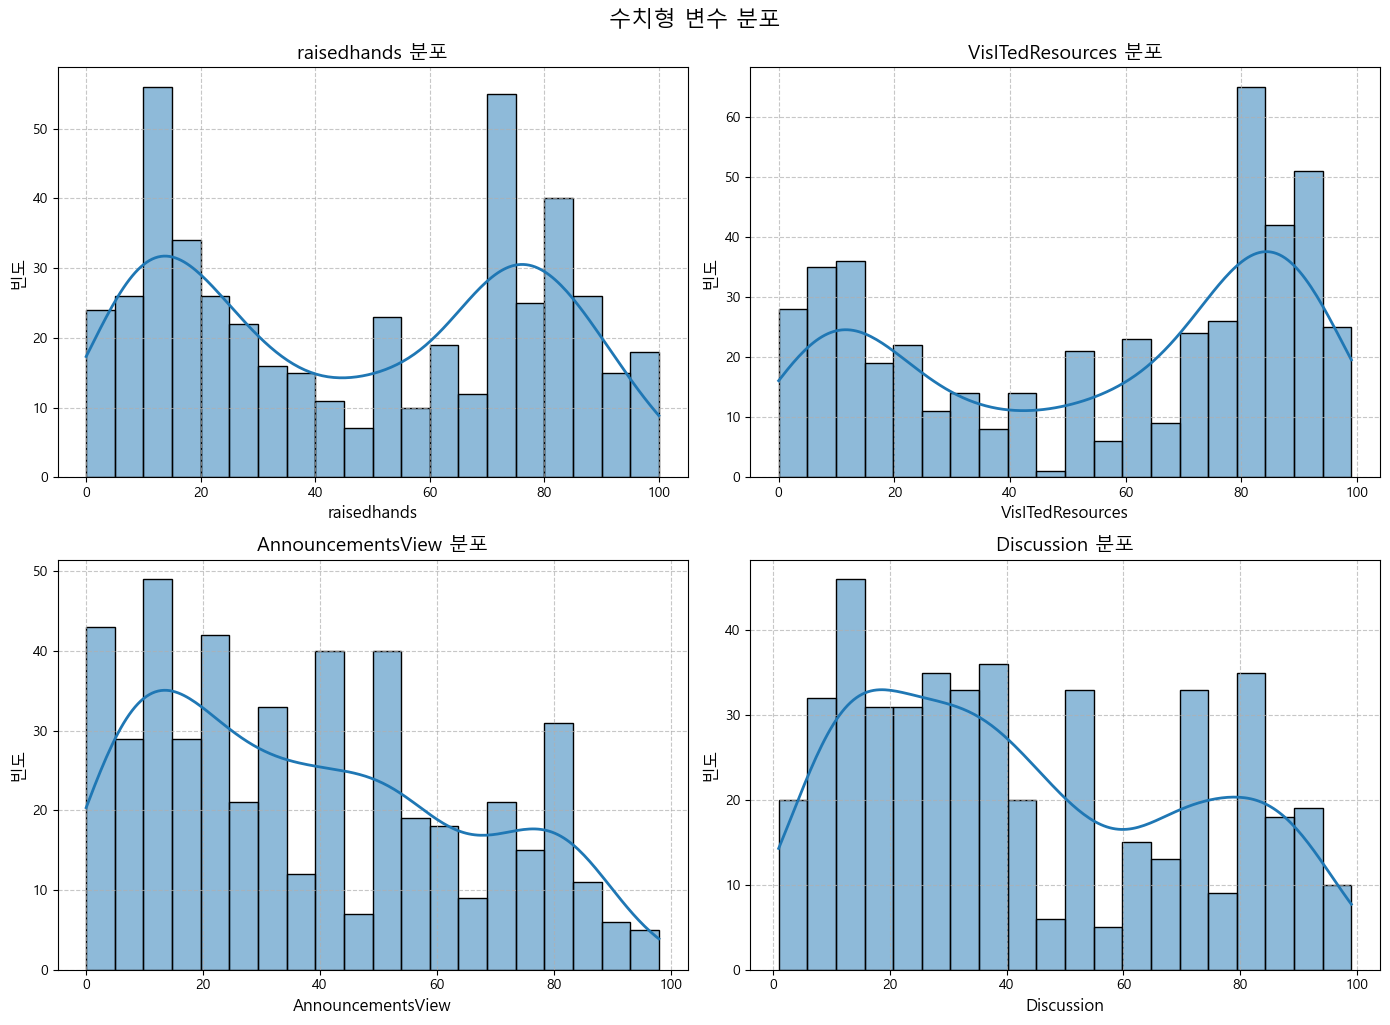

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 수치형 변수 목록
numeric_columns = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    # histplot으로 히스토그램 그리기 (kde 곡선 추가)
    sns.histplot(df[column], bins=20, kde=True, ax=axes[i], edgecolor='black', line_kws={'linewidth': 2})
    
    # 그래프 제목 및 레이블 설정
    axes[i].set_title(f'{column} 분포', fontsize=14)
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('빈도', fontsize=12)
    
    # 그리드 추가
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.suptitle('수치형 변수 분포', fontsize=16, y=1.02)
plt.show()


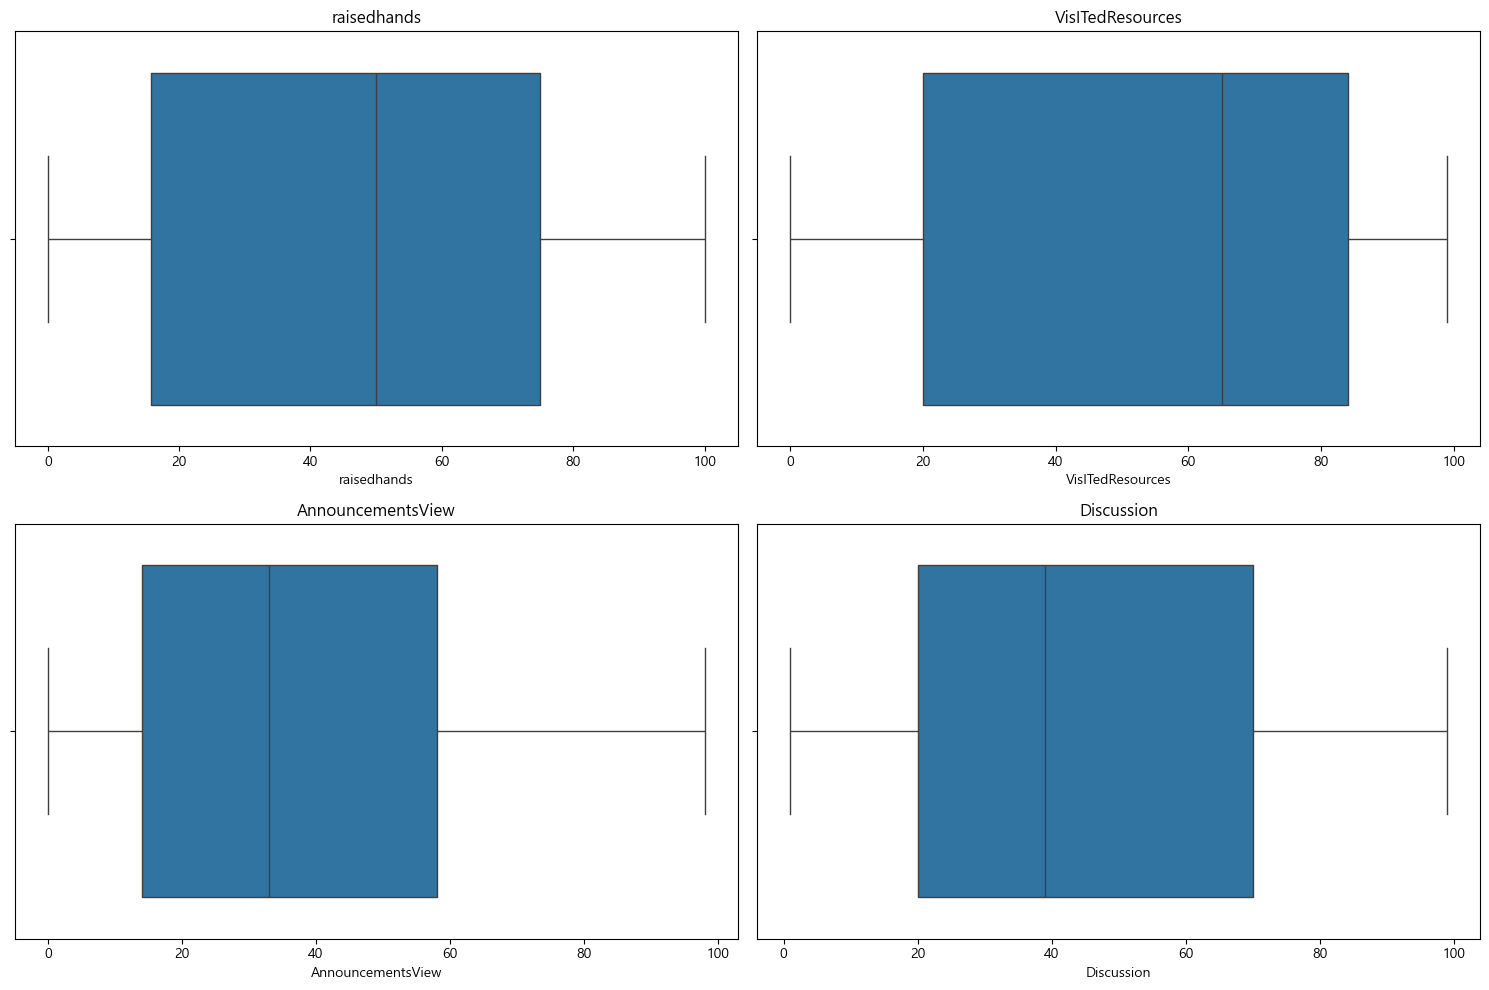

In [22]:
# 이상치 탐지 (수치형 변수에 대해)
plt.figure(figsize=(15, 10))
count = 1
for col in numeric:
        plt.subplot(2, 2, count)
        sns.boxplot(x=df[col])
        plt.title(col)
        count += 1
plt.tight_layout()
plt.show()

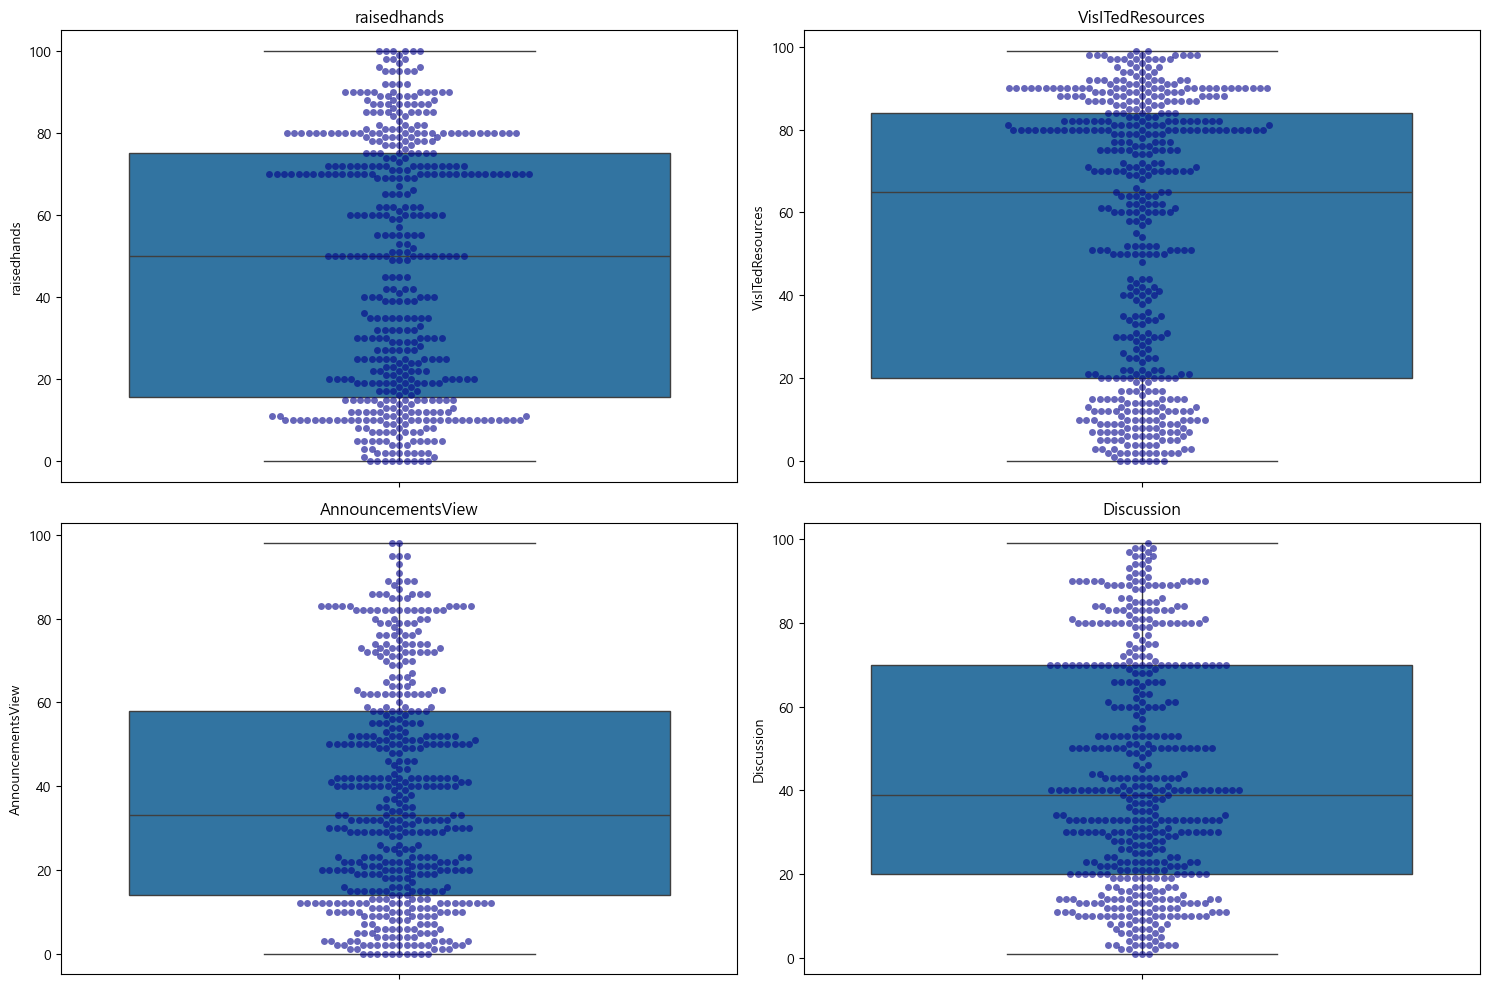

In [23]:
# 세로 boxplot과 swarmplot 함께 표시하기
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])  # 세로 방향 boxplot
    sns.swarmplot(y=df[col], color='darkblue', alpha=0.6)  # 데이터 포인트 분포 표시
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
#Class를 타겟으로 하기위해서 categorical에 Class가있다면 제거

if 'Class' in categorical:
    categorical.remove('Class')

# H 클래스 이진 타겟 생성 (H vs non-H)
df['Class_H'] = (df['Class'] == 'H').astype(int)

# 원본 Class 컬럼 제외하고 특성과 타겟 분리
X = df.drop(['Class', 'Class_H'], axis=1)
y = df['Class_H']

# 범주형 변수 원-핫 인코딩
X_encoded = pd.get_dummies(X, columns=categorical, drop_first=True)

# 인코딩된 특성과 타겟 결합
df_combined = pd.concat([X_encoded, y], axis=1)

# 상관관계 행렬 계산
correlation_matrix = df_combined.corr()


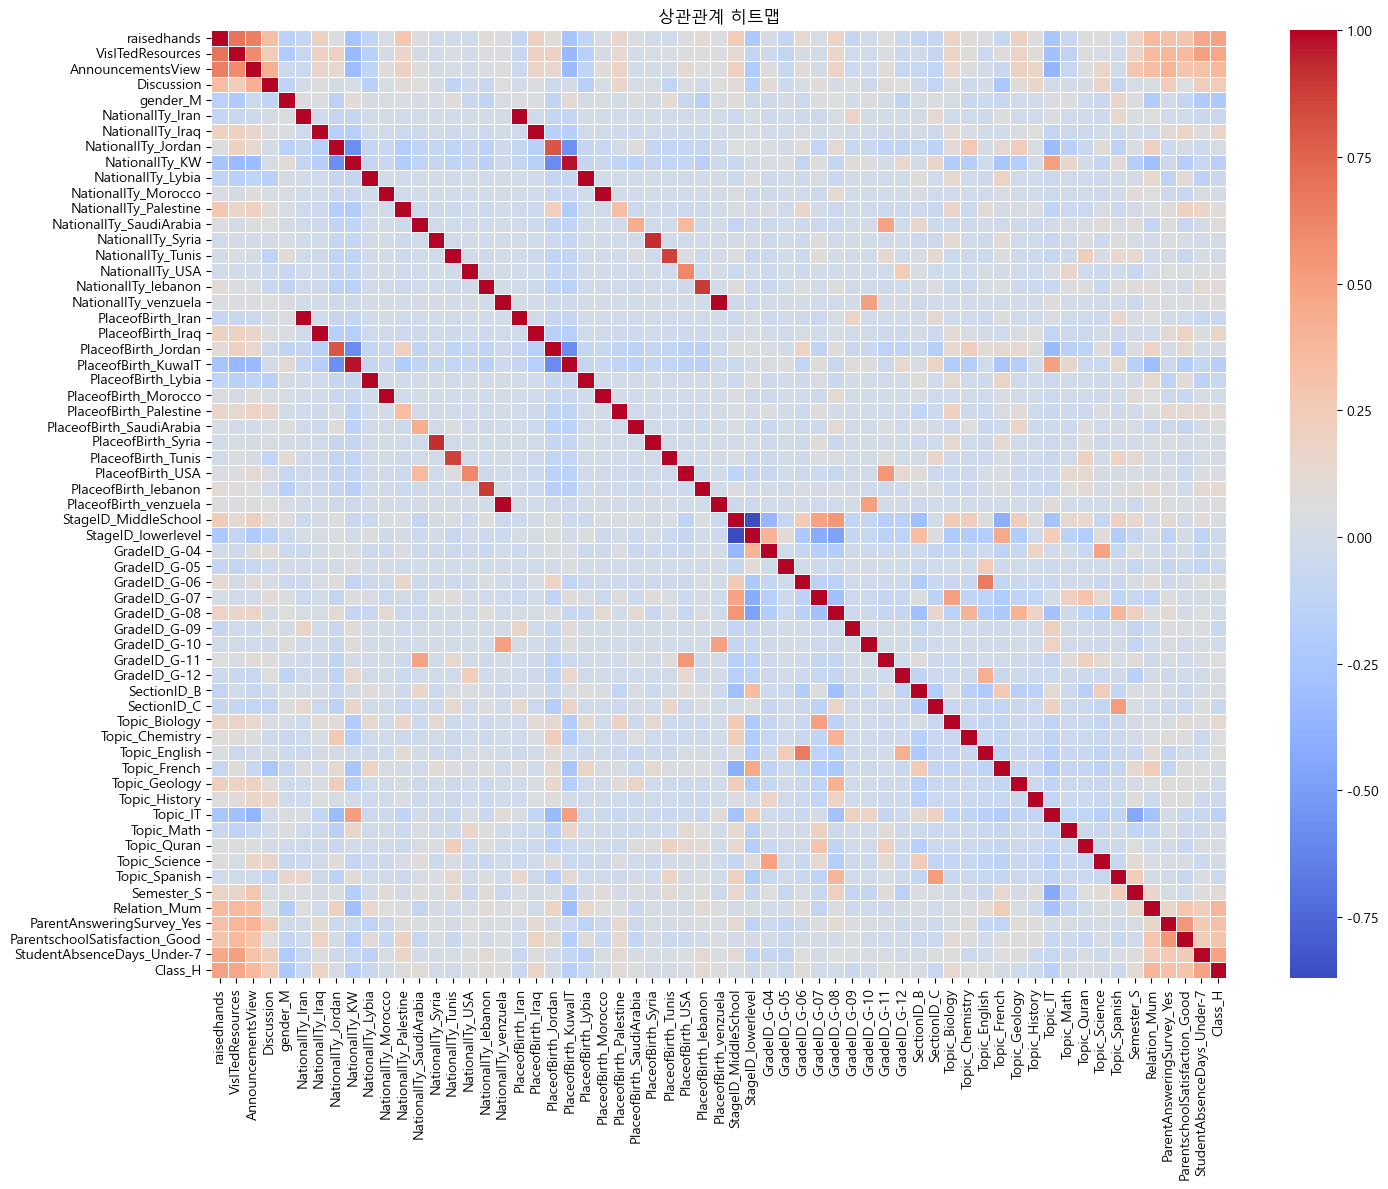

In [ ]:
#상관관계 히트맵맵
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('상관관계 히트맵')
plt.tight_layout()
plt.show()

In [29]:
# H 클래스와 상관관계가 0.2 이상인 특성 선택
target_column = 'Class_H'
target_correlations = np.abs(correlation_matrix[target_column].sort_values(ascending=False))
selected_features = target_correlations[target_correlations >= 0.2]
selected_features_cols= target_correlations[target_correlations >= 0.2].index.tolist()

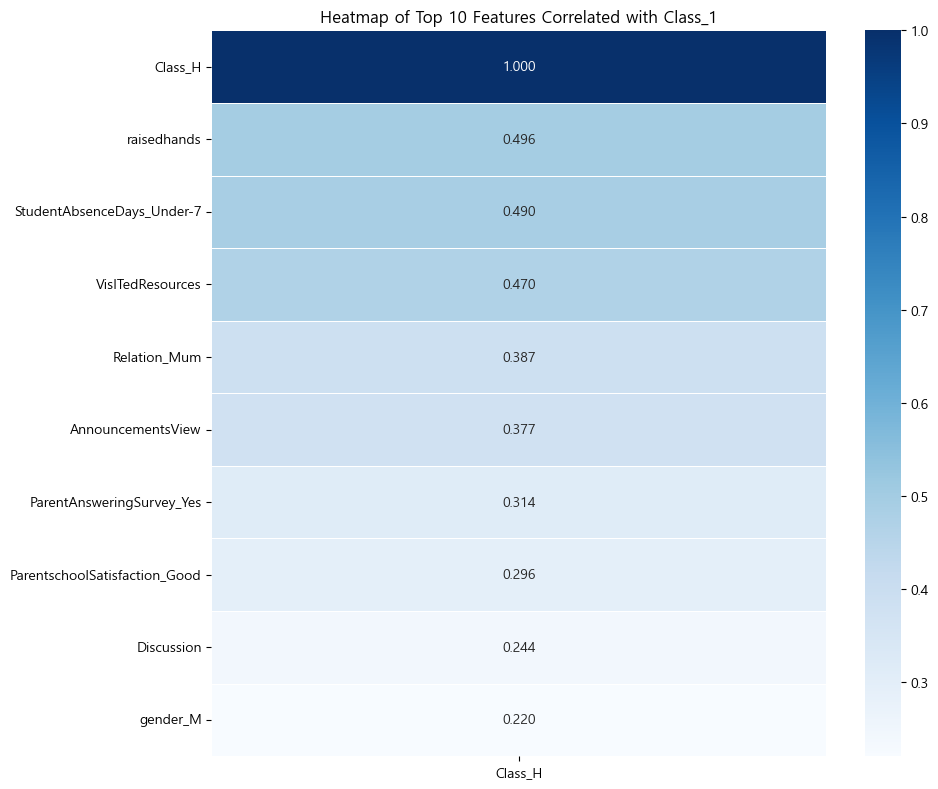

In [30]:
# 히트맵 생성
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(selected_features), annot=True, cmap='Blues', linewidths=0.5, fmt='.3f')
plt.title('Heatmap of Top 10 Features Correlated with Class_1')
plt.tight_layout()
plt.show()

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 11. 다중공선성 검사 (VIF)
X_vif = df_combined[selected_features_cols]
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n다중공선성 검사 (VIF):")
print(vif_data.sort_values('VIF', ascending=False))

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''